In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
gender_submission_df = pd.read_csv('gender_submission.csv')


In [11]:
print(train_df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [20]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [21]:
gender_submission_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [28]:
train_df.shape

(891, 12)

In [22]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Exploratory Data Analysis

In [24]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

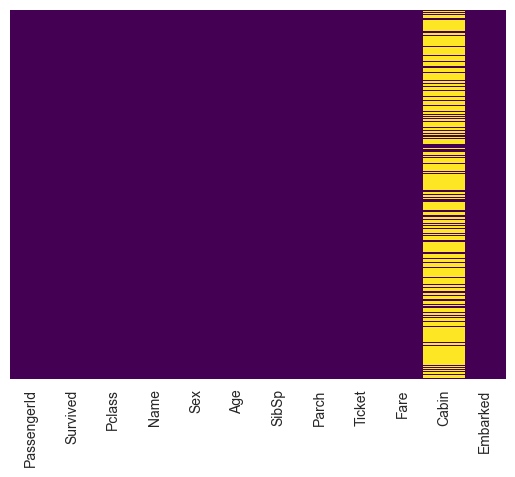

In [60]:
sns.heatmap(train_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

Roughly 20 percent of the Age data is missing.The proportion of Age missing is likely small enough for reasonable replacement with some form of imputation.
Looking at the Cabin column,it looks like we are just missing too much of that data to do something useful with at a basic level.We'll probably drop this later,or change it to another feature like 'Cabin Known:0 or

Text(0.5, 1.0, 'Survival Count')

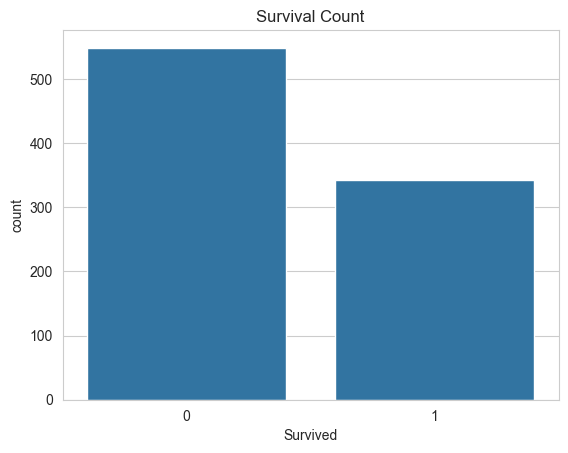

In [29]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train_df)
plt.title('Survival Count')


**Observation:**
There were more passengers who did not survive (0) more than 550 than those who did (1). that is more than 300.


<Axes: xlabel='Survived', ylabel='count'>

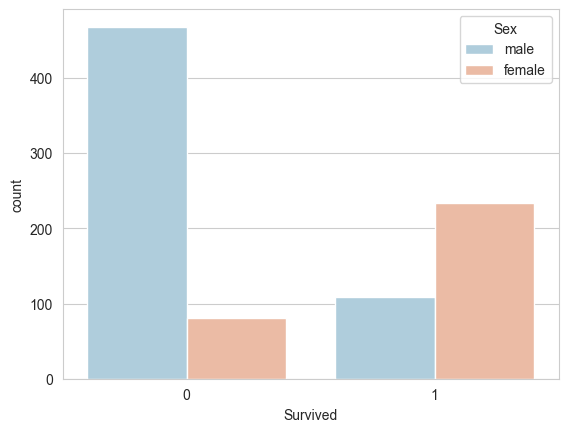

In [31]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train_df, palette="RdBu_r")


**Observation:**
most of the people those are male that is more than 450 is not servived.Wheareas significantly higher number of females survived compared to males. This suggests that women were given priority during evacuation.


<Axes: xlabel='Survived', ylabel='count'>

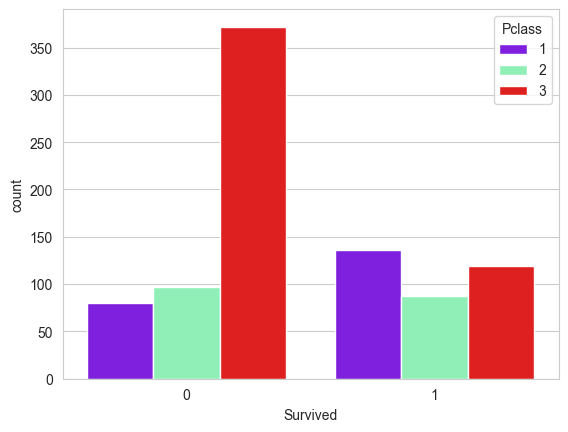

In [32]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass',data=train_df,palette='rainbow')

**Observation:**
Passengers in 1st class had a much higher survival rate compared to those in 2nd and especially 3rd class. This shows that class status played a role in survival chances.


C:\Users\Pooja\AppData\Local\Temp\ipykernel_14016\4102928446.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df["Age"].dropna(),kde=False,color="darkred",bins=40)


<Axes: xlabel='Age'>

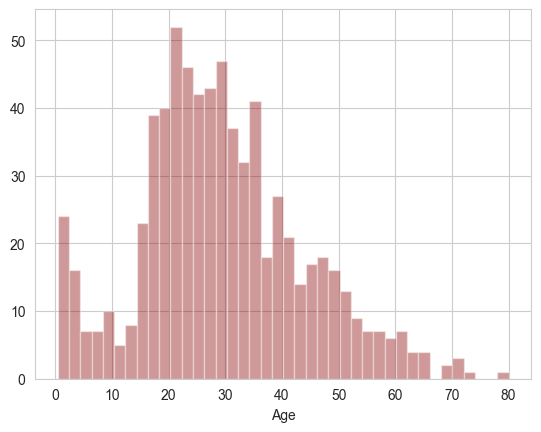

In [36]:
sns.distplot(train_df["Age"].dropna(),kde=False,color="darkred",bins=40)

<Axes: >

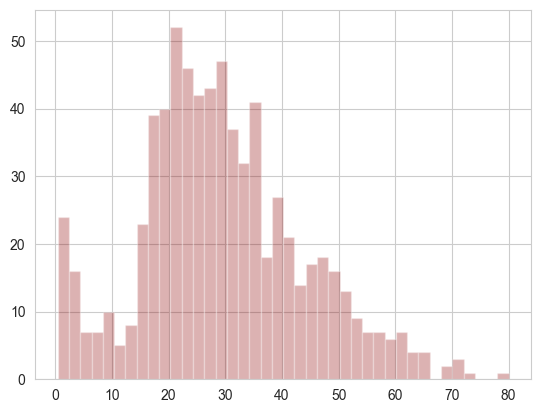

In [37]:
train_df["Age"].hist(color="darkred",bins=40,alpha=0.3)

**Observation:**
Most passengers were between 20 and 40 years old. Very few passengers were above 60, and there were some children as well.


<Axes: xlabel='SibSp', ylabel='count'>

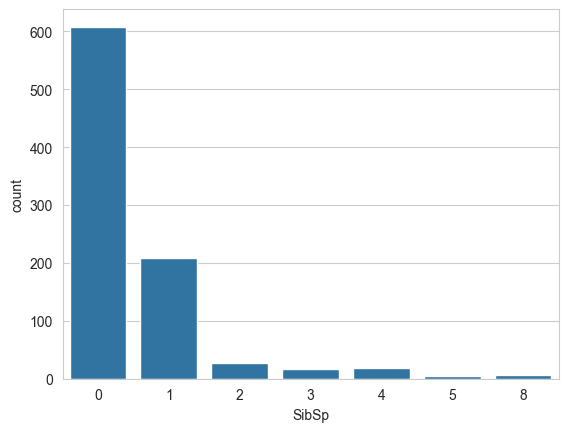

In [38]:
sns.countplot(x='SibSp',data=train_df)

**Observation:**
The majority of passengers were traveling alone or with one sibling/spouse. Very few had more than 2 siblings/spouses with them.


<Axes: >

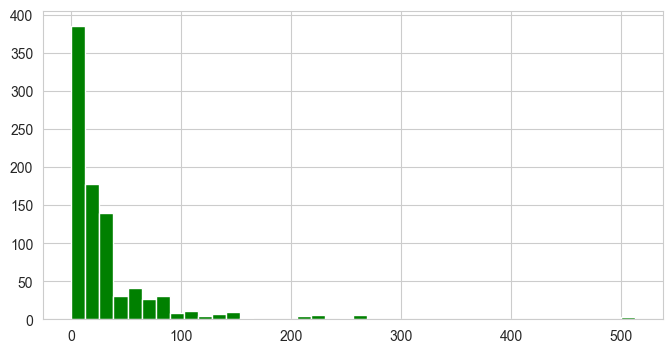

In [64]:
train_df['Fare'].hist(color='green',bins=40,figsize=(8,4))

**Observation:**
Most passengers paid a fare under $100. A few paid significantly higher fares, which likely corresponds to first-class tickets.


Data Cleaning 

We want to fill in missing Age data instead od just dropping the missing Age data rows.One way to do this by filling in the mean age of all the passangers(imputation).

C:\Users\Pooja\AppData\Local\Temp\ipykernel_14016\3472948166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=train_df,palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

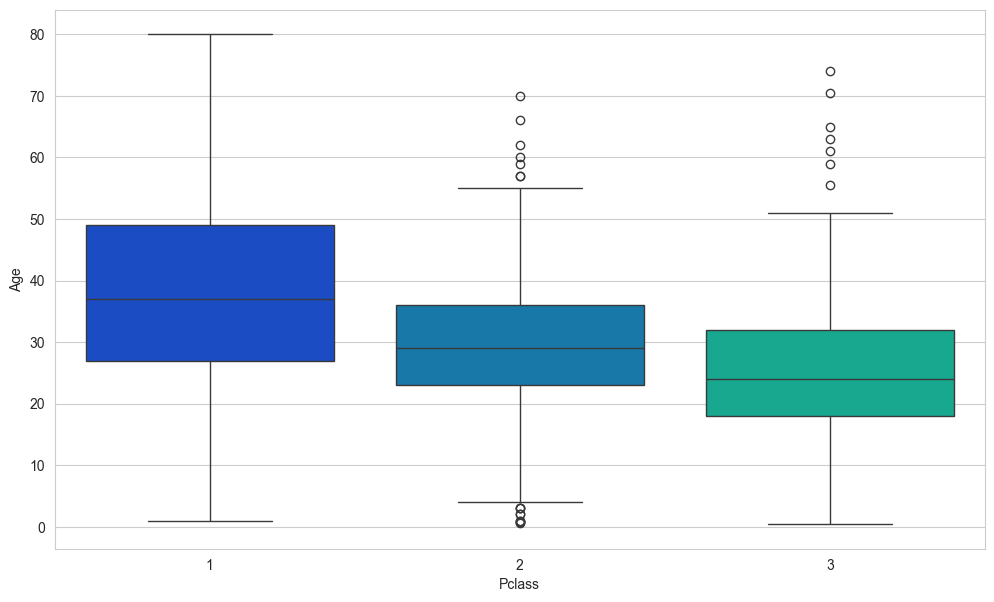

In [41]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass',y='Age',data=train_df,palette='winter')

we can see that the wealthier passagers in the higher classes trend to be older,which makes sense.
we'll use these average age values to impute based on Pclass for Age.

In [55]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37
            
        elif Pclass == 2:
            return 29
            
        else:
            return 24
    else:
        return Age
    

Now apply that funtional


In [56]:
train_df['Age'] = train_df[['Age','Pclass']].apply(impute_age,axis=1)

C:\Users\Pooja\AppData\Local\Temp\ipykernel_14016\3005635740.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\Pooja\AppData\Local\Temp\ipykernel_14016\3005635740.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


Now check that heat map again

<Axes: >

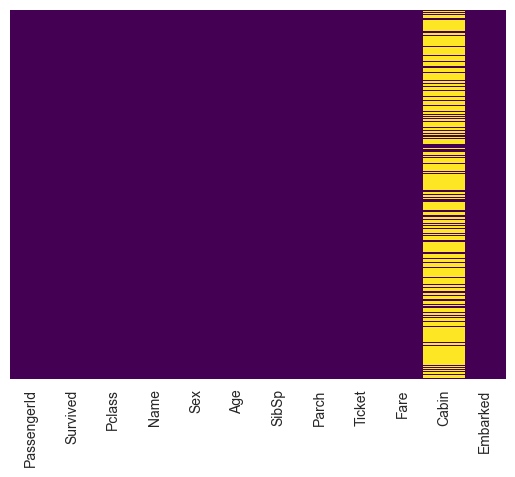

In [57]:
sns.heatmap(train_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

In [61]:
train_df.drop('Cabin',axis=1,inplace=True)

In [62]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,24.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,37.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,24.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,37.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,24.0,0,0,373450,8.0500,S


<Axes: >

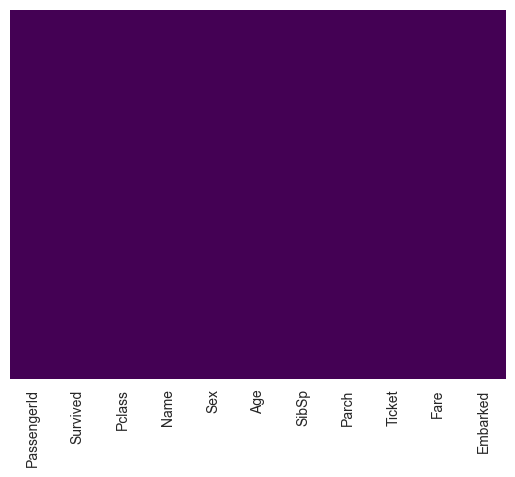

In [63]:
sns.heatmap(train_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

Text(0.5, 1.0, 'Age vs Fare (Survival)')

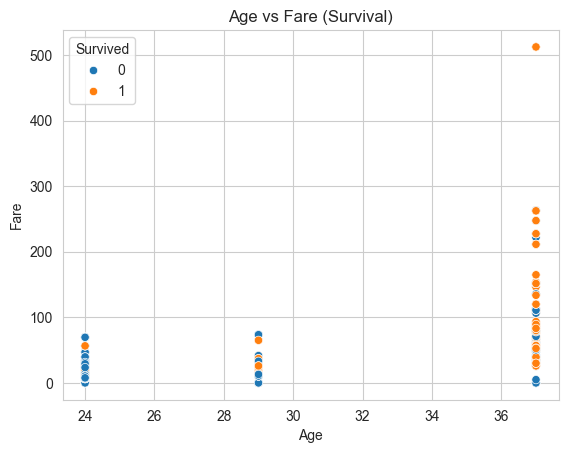

In [65]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train_df)
plt.title('Age vs Fare (Survival)')


**Observation:**
Passengers who paid higher fares were more likely to survive, especially among younger age groups. Survivors are clustered more in higher fare zones, while non-survivors are spread across all fare ranges.


<Axes: xlabel='Survived', ylabel='Age'>

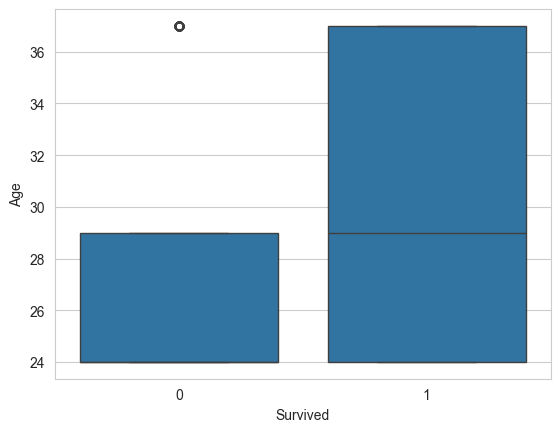

In [68]:
sns.boxplot(x='Survived', y='Age', data=train_df)


**Observation:**
The median age of survivors is slightly lower than that of non-survivors. The interquartile range for survivors is also narrower, suggesting survivors were more likely to be younger, but people of all ages were affected.


###Conclusion :
Survival on the Titanic was influenced by a combination of gender, passenger class, and fare, with females and wealthier (1st-class) passengers having the highest survival odds. Age had a moderate effect, with younger passengers showing slightly better survival rates.